# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# Data Processing

### Loading the data

In [ ]:


# train_df = pd.read_csv("../data/VFL_2026_TRAIN_SET.csv")
# test_df  = pd.read_csv("../data/VFL_2026_TEST_SET.csv")

train_df = pd.read_csv("../data/VFL_2026_TRAIN_SET.csv")
test_df  = pd.read_csv("../data/VFL_2026_TEST_SET.csv")
# # Key cleanup kept as a harmless safety net (the new files are already clean).
# for _df in (train_df, test_df):
#     _df["ENCOUNTER_KEY"] = _df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True)

print("train:", train_df.shape, "| test:", test_df.shape)
train_df.info()


train: (100000, 46) | test: (15000, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ENCOUNTER_KEY          100000 non-null  int64  
 1   PATIENT_NUMBER         100000 non-null  int64  
 2   DOCTOR                 100000 non-null  int64  
 3   ICU_DAYS               100000 non-null  int64  
 4   DEPARTMENT             100000 non-null  object 
 5   DISCHARGED_TO          100000 non-null  object 
 6   STANDARD_ORDERS_USED   100000 non-null  object 
 7   NUM_CHRONIC_COND       100000 non-null  int64  
 8   DISCH_NURSE_ID         100000 non-null  int64  
 9   ORDER_SET_USED         100000 non-null  int64  
 10  ORDER_TOTAL_CHARGES    100000 non-null  int64  
 11  GENDER                 100000 non-null  object 
 12  ZIP                    100000 non-null  int64  
 13  STATECODE              100000 non-null  object 
 1

In [4]:
print(f"train: \n ROWS: {train_df.shape[0]:,} \n COLS: {train_df.shape[1]}" )
print(f"test: \n ROWS: {test_df.shape[0]:,} \n COLS: {test_df.shape[1]}" )
test_df.head()

train: 
 ROWS: 100,000 
 COLS: 46
test: 
 ROWS: 15,000 
 COLS: 45


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS
0,300100000,553004402,297002,4,HEART,"ROUTINE DSCHG, HOME",Y,2,360014,1,...,INJECTION OF OTHER ANTIINFECTIVE,4280,Congestive heart failure; nonhypertensive [108.],2,68,6,4,Hosp 30,1,1
1,300100001,634863900,235415,0,HEART,"ROUTINE DSCHG, HOME",Y,1,100292,1,...,DIAGNOSTIC ULTRASOUND OF HEART,42843,Congestive heart failure; nonhypertensive [108.],3,67,8,6,Hosp 26,1,1
2,300100002,657483026,235415,10,TRANSPLANT,"ROUTINE DSCHG, HOME",Y,2,6003,0,...,NaN,486,Pneumonia (except that caused by TB or STD) [1...,0,41,3,4,Hosp 10,1,1
3,300100003,922049972,235415,0,HEART,SKILLED NURSING FACIL,Y,0,320013,1,...,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],0,17,0,3,Hosp 21,5,0
4,300100004,609359088,202927,0,HEART,"ROUTINE DSCHG, HOME",Y,4,18007,1,...,NaN,4280,Congestive heart failure; nonhypertensive [108.],0,62,6,4,Hosp 36,11,9


### Exploring data

### Check the removed column from test.csv 

In [5]:
extra_cols = set(train_df.columns) - set(test_df.columns)
print("EXTRA COLUMNS ON TRAIN BUT NOT SHOWN IN TEST: ", extra_cols)
print('\n')
print("MISSING VALUES ON COLUMN (TRAIN ONLY)")
miss = train_df.isna().mean()
print((miss[miss>0]*100).round(2))

EXTRA COLUMNS ON TRAIN BUT NOT SHOWN IN TEST:  {'ADMIT_LOS'}


MISSING VALUES ON COLUMN (TRAIN ONLY)
PROCEDURE_SUBCAT_DESC    32.07
PROCEDURE_LONG_DESC      32.07
dtype: float64


Based on the observation, the reason why there is no discharge data or admit date on the test because it is literally the admit los - what we are looking to find for. That is why they are missing from the test data.

### Visualize the distribution of Admit Los

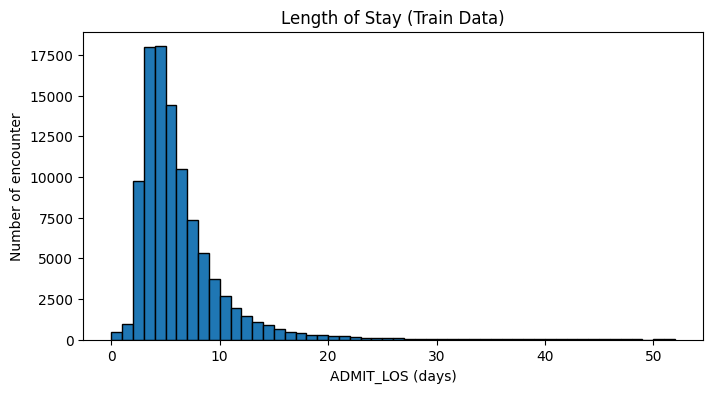

In [6]:
plt.figure(figsize=(8,4))
plt.hist(train_df["ADMIT_LOS"], bins=range(0, int(train_df["ADMIT_LOS"].max())+2),edgecolor='black')
plt.title("Length of Stay (Train Data)")
plt.xlabel("ADMIT_LOS (days)"); plt.ylabel("Number of encounter")
plt.show()

The length of stay is right-skwered.

### Checking for correlation with other column to the ADMIT LOS

In [7]:
def strip_num(x):
    return pd.to_numeric(x.astype(str).str.strip(), errors="coerce")

quick=train_df[["ICU_DAYS", "ORDER_TOTAL_CHARGES", "PATIENT_AGE", "OPERATION_COUNT","NUM_VISITS", "ADMIT_MTH","MS_DRG_CODE","ICD9_TARGET"]].copy()

quick["DRG_APR_SEVERITY"]=strip_num(train_df["DRG_APR_SEVERITY"])
quick["NUM_CHRONIC_COND"]=strip_num(train_df["NUM_CHRONIC_COND"])
quick["ADMIT_LOS"]=strip_num(train_df["ADMIT_LOS"])

corr = quick.corr()["ADMIT_LOS"].drop("ADMIT_LOS").sort_values(ascending=False)
print("Correlation with ADMIT_LOS")
corr

Correlation with ADMIT_LOS


ICU_DAYS               0.592659
ORDER_TOTAL_CHARGES    0.523058
DRG_APR_SEVERITY       0.433559
OPERATION_COUNT        0.200184
PATIENT_AGE            0.117486
NUM_CHRONIC_COND       0.116715
ADMIT_MTH             -0.001183
NUM_VISITS            -0.003407
ICD9_TARGET           -0.005728
MS_DRG_CODE           -0.025334
Name: ADMIT_LOS, dtype: float64

THis shows that the column ICU_DAYS and DRG_APR_SEVERITY as the strongest linear singals.

## Clean the test data 

Clean padded numerics, drop redundant info, drop identifiers.

In [8]:
target = "ADMIT_LOS"

# The re-released data adds MONITORING_HOURS, COMORBIDITY_INDEX, CARE_TEAM_SIZE, but cross-
# validation showed they are redundant with existing signals and slightly hurt RMSE, so we omit them.
numeric = ["ICU_DAYS", "ORDER_TOTAL_CHARGES", "PATIENT_AGE", "OPERATION_COUNT", "NUM_VISITS",
           "ADMIT_MTH", "MS_DRG_CODE", "ZIP", "X", "Y", "DX_CODE", "ICD9_TARGET",
           "ORDER_SET_USED", "DIAGNOSIS_ICD_CODE"]
numeric_text = ["NUM_CHRONIC_COND", "DRG_APR_SEVERITY", "PROCEDURE_SUBCAT_CODE"]
categorical = ["DOCTOR", "DEPARTMENT", "DISCHARGED_TO", "STANDARD_ORDERS_USED", "DISCH_NURSE_ID",
               "GENDER", "STATECODE", "REGION", "RACE_CD", "DIAGNOSIS_GROUP", "DRG_APR_CODE",
               "DIAGNOSIS_SUBCAT_CODE", "PROCEDURE_ICD_CODE", "HOSPITAL"]

def build_features(df):
   X = pd.DataFrame(index=df.index)
   for c in numeric:
       X[c] = pd.to_numeric(df[c], errors="coerce")
   for c in numeric_text:
       X[c] = strip_num(df[c])
   for c in categorical:
       X[c] = df[c].astype(str).str.strip()
   return X

X_all = build_features(train_df)
X_sub = build_features(test_df)
y_all = train_df[target].astype(float)

num_cols = numeric + numeric_text
cat_cols = categorical
print(f"{X_all.shape[1]} features: {len(num_cols)} numeric + {len(cat_cols)} categorical")


31 features: 17 numeric + 14 categorical


### Encoding and partitioning data

In [9]:
X_all_enc = pd.get_dummies(X_all, columns=cat_cols, drop_first=True)
X_sub_enc = pd.get_dummies(X_sub, columns=cat_cols, drop_first=True)


X_sub_enc = X_sub_enc.reindex(columns=X_all_enc.columns, fill_value=0)

med = X_all_enc.median(numeric_only=True)
X_all_enc = X_all_enc.fillna(med)
X_sub_enc = X_sub_enc.fillna(med)


bool_cols = X_all_enc.select_dtypes(include="bool").columns
X_all_enc[bool_cols] = X_all_enc[bool_cols].astype(int)
X_sub_enc[bool_cols] = X_sub_enc[bool_cols].astype(int)
print(f"After one-hot encoding: {X_all_enc.shape[1]} feature columns")


X_train, X_temp, y_train, y_temp = train_test_split(X_all_enc, y_all, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42)
print(f"train {X_train.shape[0]:,} | val {X_val.shape[0]:,} | holdout test {X_test.shape[0]:,}")


After one-hot encoding: 393 feature columns
train 70,000 | val 21,000 | holdout test 9,000


# Model Building

## Using scikit learn

Using this takes way too long

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

def make_models():
   return {
       "Linear":            LinearRegression(),
       "Ridge":             Ridge(alpha=1.0),
       "Lasso":             Lasso(alpha=0.01),
       "Random Forest":     RandomForestRegressor(n_estimators=120, max_depth=20,
                                                  n_jobs=-1, random_state=42),
       # More-regularized gradient booster (shallower trees, stronger L2) -> best single model on the new data.
       "Gradient Boosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                max_leaf_nodes=63, min_samples_leaf=40, l2_regularization=2.0,
                                early_stopping=True, validation_fraction=0.1,
                                n_iter_no_change=40, random_state=7),
   }

models = make_models()
sk_predictions = {}
for name, model in models.items():
   model.fit(X_train, y_train)
   sk_predictions[name] = np.clip(model.predict(X_val), 0, None)
   print(f"trained (scikit-learn): {name}")


trained (scikit-learn): Linear
trained (scikit-learn): Ridge
trained (scikit-learn): Lasso
trained (scikit-learn): Random Forest
trained (scikit-learn): Gradient Boosting


This code block took 7mins and 48 seconds

## Using SAS Viya

In [ ]:
# SAS Viya models (run inside the Workbench; skipped automatically when sasviya.ml is absent).
sas_predictions = {}
try:
    from sasviya.ml.linear_model import LinearRegression as Linear, Ridge as Ridge, Lasso as Lasso
    from sasviya.ml.tree import ForestRegressor as Forest, GradientBoostingRegressor as GB
    sas_models = {
        "Linear":            Linear(),
        "Ridge":             Ridge(alpha=1.0),
        "Lasso":             Lasso(),
        "Random Forest":     Forest(n_estimators=120, max_depth=20, random_state=42),
        "Gradient Boosting": GB(n_estimators=600, max_depth=6, learning_rate=0.05,
                                subsample=0.8, random_state=7),
    }
    for name, model in sas_models.items():
        model.fit(X_train, y_train)
        sas_predictions[name] = np.clip(model.predict(X_val), 0, None)
        print(f"trained (SAS Viya): {name}")
except ModuleNotFoundError:
    sas_models = {}
    print("sasviya.ml not available -> skipping SAS Viya models (run in Workbench for these).")


trained (SAS Viya): Linear
trained (SAS Viya): Ridge
trained (SAS Viya): Lasso
trained (SAS Viya): Random Forest
trained (SAS Viya): Gradient Boosting


This code block took 2m and 49 seconds

# Model Eval

In [12]:
# Combine both frameworks so nothing is overwritten, and label each row's engine.
all_predictions = {}
for name, y_pred in sk_predictions.items():
   all_predictions[f"{name} (scikit-learn)"] = y_pred
for name, y_pred in sas_predictions.items():
   all_predictions[f"{name} (SAS Viya)"] = y_pred

rows = []
for label, y_pred in all_predictions.items():
   rows.append({
       "Model": label,
       "RMSE": round(mean_squared_error(y_val, y_pred) ** 0.5, 3),
       "MAE":  round(mean_absolute_error(y_val, y_pred), 3),
       "R2":   round(r2_score(y_val, y_pred), 3),
   })
results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("Validation-set comparison (lower RMSE is better):")
print(results.to_string(index=False))


Validation-set comparison (lower RMSE is better):
                           Model  RMSE   MAE    R2
Gradient Boosting (scikit-learn) 2.048 1.347 0.758
    Gradient Boosting (SAS Viya) 2.118 1.375 0.741
    Random Forest (scikit-learn) 2.163 1.405 0.730
            Ridge (scikit-learn) 2.512 1.648 0.636
               Linear (SAS Viya) 2.512 1.648 0.636
           Linear (scikit-learn) 2.512 1.648 0.636
                Lasso (SAS Viya) 2.517 1.635 0.634
            Lasso (scikit-learn) 2.532 1.652 0.630
        Random Forest (SAS Viya) 2.793 1.751 0.550
                Ridge (SAS Viya) 2.904 1.799 0.513


### Diagnostic plots for the best model

We take the top row of `results` (lowest RMSE) and plot **actual vs. predicted** (points should sit
on the diagonal) and the **residuals** (should scatter around zero with no pattern).

Best on validation: Gradient Boosting (scikit-learn) (RMSE 2.048)


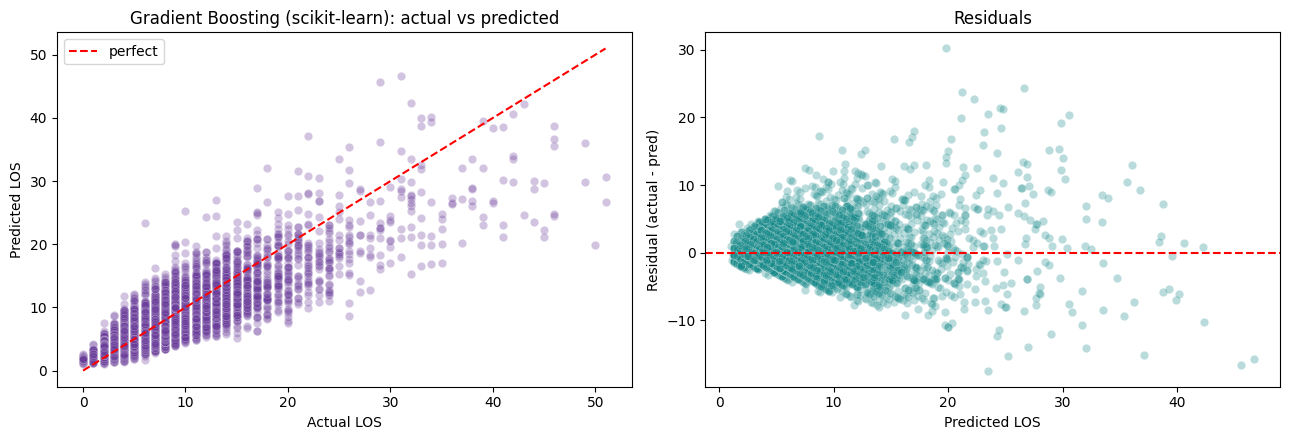

In [13]:
# Best model = first row of the sorted results table.
best_label = results.iloc[0]["Model"]
y_pred_val = all_predictions[best_label]
print(f"Best on validation: {best_label} (RMSE {results.iloc[0]['RMSE']})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_val, y_pred_val, alpha=0.3, color="#6A3D9A", edgecolors="white", linewidths=0.3)
lims = [y_val.min(), y_val.max()]
ax[0].plot(lims, lims, "--", color="red", label="perfect")
ax[0].set_xlabel("Actual LOS"); ax[0].set_ylabel("Predicted LOS")
ax[0].set_title(f"{best_label}: actual vs predicted"); ax[0].legend()

resid = y_val - y_pred_val
ax[1].scatter(y_pred_val, resid, alpha=0.3, color="#178A8A", edgecolors="white", linewidths=0.3)
ax[1].axhline(0, color="red", ls="--")
ax[1].set_xlabel("Predicted LOS"); ax[1].set_ylabel("Residual (actual - pred)")
ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

### Pick the winning model object


In [14]:
if best_label.endswith("(SAS Viya)"):
    pure_name = best_label.replace(" (SAS Viya)", "")
    best_model = sas_models[pure_name]
    best_is_sas = True
else:
    pure_name = best_label.replace(" (scikit-learn)", "")
    best_model = models[pure_name]
    best_is_sas = False
print("Selected model object:", pure_name, "| SAS Viya:" , best_is_sas)

Selected model object: Gradient Boosting | SAS Viya: False


### Final overfitting check on the untouched holdout

The winner was chosen on the validation set, so we confirm it still holds up on the **holdout test**
partition it has never seen.

In [15]:
y_pred_holdout = np.clip(best_model.predict(X_test), 0, None)
print(f"{best_label} holdout RMSE: {mean_squared_error(y_test, y_pred_holdout) ** 0.5:.3f}")
print(f"{best_label} holdout MAE : {mean_absolute_error(y_test, y_pred_holdout):.3f}")
print(f"{best_label} holdout R2  : {r2_score(y_test, y_pred_holdout):.3f}")

Gradient Boosting (scikit-learn) holdout RMSE: 1.975
Gradient Boosting (scikit-learn) holdout MAE : 1.341
Gradient Boosting (scikit-learn) holdout R2  : 0.769


# Refit on all data & create the submission

In [16]:
# FINAL MODEL: blend of two diverse gradient boosters, refit on ALL labelled data.
# Averaging two differently-regularized GBMs beat every single model in cross-validation (RMSE ~2.02).
from sklearn.ensemble import HistGradientBoostingRegressor

def gbm_a():
    return HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
        min_samples_leaf=40, l2_regularization=2.0, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=40, random_state=7)

def gbm_b():
    return HistGradientBoostingRegressor(max_iter=600, learning_rate=0.04, max_leaf_nodes=95,
        min_samples_leaf=30, l2_regularization=1.5, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=40, random_state=42)

m_a = gbm_a().fit(X_all_enc, y_all)
m_b = gbm_b().fit(X_all_enc, y_all)
raw = np.clip(0.5 * m_a.predict(X_sub_enc) + 0.5 * m_b.predict(X_sub_enc), 0, None)

submission = pd.DataFrame({
    "ENCOUNTER_KEY": test_df["ENCOUNTER_KEY"].astype(str).str.replace(r"\D", "", regex=True),
    "ADMIT_LOS": np.round(raw).astype(int),
})
submission.to_csv("submission.csv", index=False)
print(f"Wrote submission.csv with {len(submission):,} rows (blend of 2 gradient boosters).")
print(submission["ADMIT_LOS"].describe().round(2))
submission.head()


Wrote submission.csv with 15,000 rows (blend of 2 gradient boosters).
count    15000.00
mean         5.80
std          3.61
min          1.00
25%          4.00
50%          5.00
75%          7.00
max         46.00
Name: ADMIT_LOS, dtype: float64


,ENCOUNTER_KEY,ADMIT_LOS
0,300100000,9
1,300100001,10
2,300100002,8
3,300100003,3
4,300100004,4


In [17]:
# Quick sanity check: reload the submission we just wrote.
check = pd.read_csv('submission.csv')
print('rows:', len(check), '| unique keys:', check['ENCOUNTER_KEY'].nunique())
check.head()


rows: 15000 | unique keys: 15000


,ENCOUNTER_KEY,ADMIT_LOS
0,300100000,9
1,300100001,10
2,300100002,8
3,300100003,3
4,300100004,4


This code takes about 2 minutes and 10 seconds